In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score
from xgboost import XGBClassifier
import pandas as pd


X_train=pd.read_csv("X_train.csv")
X_test=pd.read_csv("X_test.csv")
y_train=pd.read_csv("y_train.csv")
y_test=pd.read_csv("y_test.csv")



print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)
print("Fraud ratio in train:", y_train.value_counts(normalize=True))
print("Fraud ratio in test:", y_test.value_counts(normalize=True))


Training set shape: (133733, 825)
Testing set shape: (33434, 825)
Fraud ratio in train: label
1        0.910269
0        0.089731
Name: proportion, dtype: float64
Fraud ratio in test: label
1        0.910271
0        0.089729
Name: proportion, dtype: float64


In [3]:
!pip install xgboost


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.7/131.7 MB 3.4 MB/s eta 0:00:00m eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 289.8/289.8 MB 1.0 MB/s eta 0:00:00m eta 0:00:010:00:08
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [xgboost]━━━ 1/2 [xgboost]


In [8]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression Results")
print(classification_report(y_test, y_pred_lr))


/home/bishhh/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Logistic Regression Results
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      3000
           1       1.00      1.00      1.00     30434

    accuracy                           1.00     33434
   macro avg       1.00      1.00      1.00     33434
weighted avg       1.00      1.00      1.00     33434



In [9]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Results")
print(classification_report(y_test, y_pred_rf))


/home/bishhh/anaconda3/lib/python3.13/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Random Forest Results
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3000
           1       1.00      1.00      1.00     30434

    accuracy                           1.00     33434
   macro avg       1.00      1.00      1.00     33434
weighted avg       1.00      1.00      1.00     33434



In [10]:
print(rf.n_features_in_)          # will print 820
print(list(X_train.columns))      # copy this output

825
['url_length', 'hostname_length', 'count_dots', 'count_hyphens', 'count_at', 'count_question', 'count_equals', 'count_digits', 'count_special_chars', 'use_ip', 'https', 'shortened_url', 'contains_login', 'contains_verify', 'contains_update', 'contains_bank', 'contains_secure', 'contains_free', 'contains_account', 'suspicious_word_count', 'num_subdirectories', 'num_subdomains', 'tld_risk_score', 'entropy', 'source_encoded', 'tld_type_', 'tld_type_ab.ca', 'tld_type_ac', 'tld_type_ac.at', 'tld_type_ac.bd', 'tld_type_ac.be', 'tld_type_ac.cn', 'tld_type_ac.cr', 'tld_type_ac.cy', 'tld_type_ac.fj', 'tld_type_ac.id', 'tld_type_ac.il', 'tld_type_ac.in', 'tld_type_ac.ir', 'tld_type_ac.jp', 'tld_type_ac.ke', 'tld_type_ac.kr', 'tld_type_ac.lk', 'tld_type_ac.ma', 'tld_type_ac.nz', 'tld_type_ac.rs', 'tld_type_ac.th', 'tld_type_ac.uk', 'tld_type_ac.za', 'tld_type_actor', 'tld_type_ad', 'tld_type_ad.jp', 'tld_type_adm.br', 'tld_type_adv.br', 'tld_type_ae', 'tld_type_aero', 'tld_type_agency', 'tld_

In [11]:
xgb = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print("XGBoost Results")
print(classification_report(y_test, y_pred_xgb))


/home/bishhh/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [17:00:14] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Results
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3000
           1       1.00      1.00      1.00     30434

    accuracy                           1.00     33434
   macro avg       1.00      1.00      1.00     33434
weighted avg       1.00      1.00      1.00     33434



In [12]:
import joblib, pickle

joblib.dump(lr,  "model_lr.pkl")
joblib.dump(rf,  "model_rf.pkl")
joblib.dump(xgb, "model_xgb.pkl")

pickle.dump(list(X_train.columns), open("feature_names.pkl", "wb"))

print("✅ Exported all 3 models +", len(X_train.columns), "feature names")

✅ Exported all 3 models + 825 feature names


In [13]:
feature_names = X_train.columns.tolist()
print(feature_names) 
with open('feature_names.pkl', 'wb') as f:
    pickle.dump(feature_names, f)

['url_length', 'hostname_length', 'count_dots', 'count_hyphens', 'count_at', 'count_question', 'count_equals', 'count_digits', 'count_special_chars', 'use_ip', 'https', 'shortened_url', 'contains_login', 'contains_verify', 'contains_update', 'contains_bank', 'contains_secure', 'contains_free', 'contains_account', 'suspicious_word_count', 'num_subdirectories', 'num_subdomains', 'tld_risk_score', 'entropy', 'source_encoded', 'tld_type_', 'tld_type_ab.ca', 'tld_type_ac', 'tld_type_ac.at', 'tld_type_ac.bd', 'tld_type_ac.be', 'tld_type_ac.cn', 'tld_type_ac.cr', 'tld_type_ac.cy', 'tld_type_ac.fj', 'tld_type_ac.id', 'tld_type_ac.il', 'tld_type_ac.in', 'tld_type_ac.ir', 'tld_type_ac.jp', 'tld_type_ac.ke', 'tld_type_ac.kr', 'tld_type_ac.lk', 'tld_type_ac.ma', 'tld_type_ac.nz', 'tld_type_ac.rs', 'tld_type_ac.th', 'tld_type_ac.uk', 'tld_type_ac.za', 'tld_type_actor', 'tld_type_ad', 'tld_type_ad.jp', 'tld_type_adm.br', 'tld_type_adv.br', 'tld_type_ae', 'tld_type_aero', 'tld_type_agency', 'tld_type

In [10]:
mlp = MLPClassifier(hidden_layer_sizes=(64,32), max_iter=300, random_state=42)
mlp.fit(X_train, y_train)

y_pred_mlp = mlp.predict(X_test)

print("Neural Network (MLP) Results")
print(classification_report(y_test, y_pred_mlp))


/home/bishhh/anaconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:1124: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Neural Network (MLP) Results
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3000
           1       1.00      1.00      1.00     30434

    accuracy                           1.00     33434
   macro avg       0.99      1.00      0.99     33434
weighted avg       1.00      1.00      1.00     33434



In [11]:
models = {
    "Logistic Regression": lr,
    "Random Forest": rf,
    "XGBoost": xgb,
    "Neural Network": mlp
}

results = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results.append([name, acc])

results_df = pd.DataFrame(results, columns=["Model", "Accuracy"])
print(results_df)


                 Model  Accuracy
0  Logistic Regression  0.999342
1        Random Forest  1.000000
2              XGBoost  1.000000
3       Neural Network  0.998325


In [ ]:
############################################ compare data 

In [12]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


In [14]:
# Example: models dictionary
models = {
    "Logistic Regression":lr,
    "Random Forest":rf,
    "XGBoost":xgb
}

# Store metrics
metrics_list = []

# Assuming X_test, y_test are ready
for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]  # probability of class 1 (fraud)
    
    metrics_list.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })
    
# Create comparison DataFrame
metrics_df = pd.DataFrame(metrics_list)
print(metrics_df)


                 Model  Accuracy  Precision   Recall        F1   ROC-AUC
0  Logistic Regression  0.999342   0.999967  0.99931  0.999638  0.999931
1        Random Forest  1.000000   1.000000  1.00000  1.000000  1.000000
2              XGBoost  1.000000   1.000000  1.00000  1.000000  1.000000


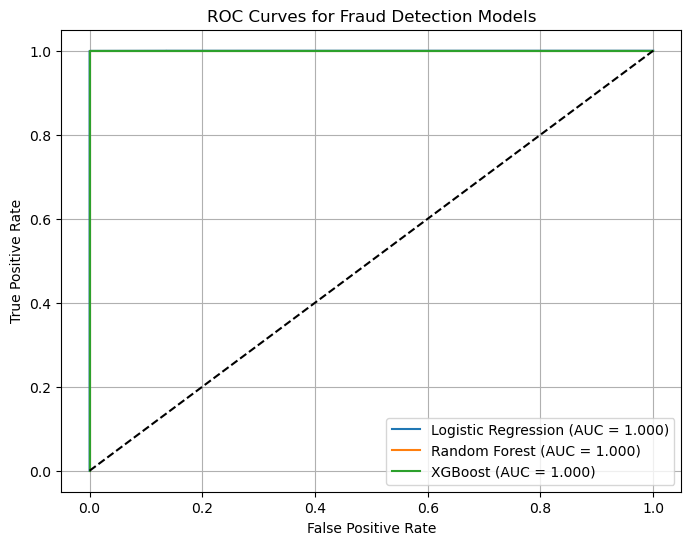

In [15]:
plt.figure(figsize=(8,6))
for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0,1], [0,1], 'k--')  # diagonal line
plt.title("ROC Curves for Fraud Detection Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


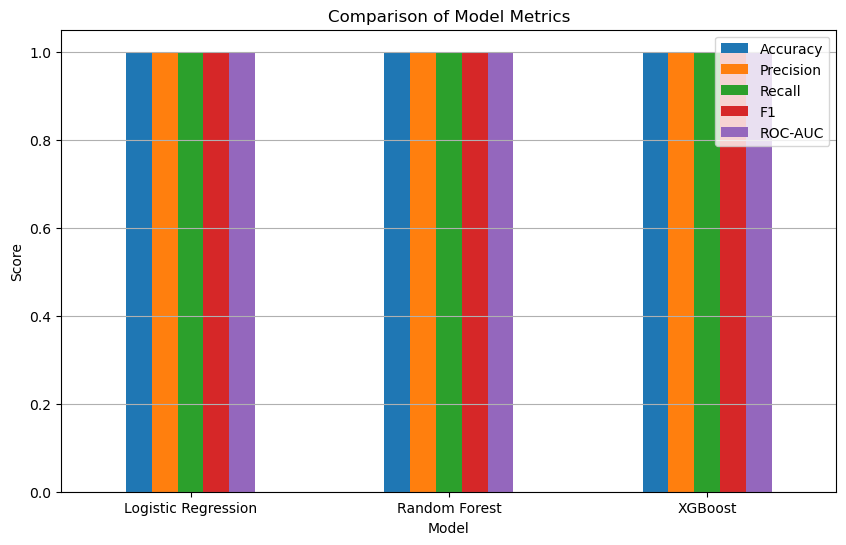

In [16]:
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]

metrics_df.set_index("Model")[metrics_to_plot].plot(
    kind="bar", figsize=(10,6), ylim=(0,1.05)
)
plt.title("Comparison of Model Metrics")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()


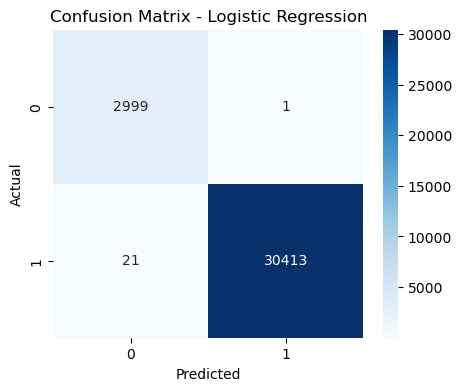

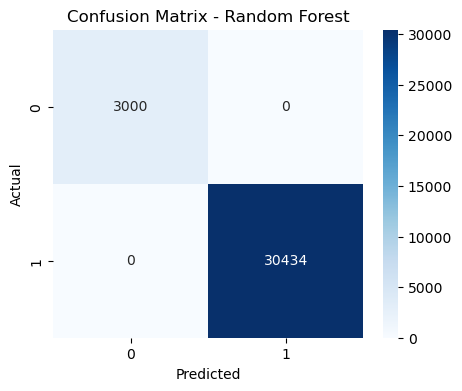

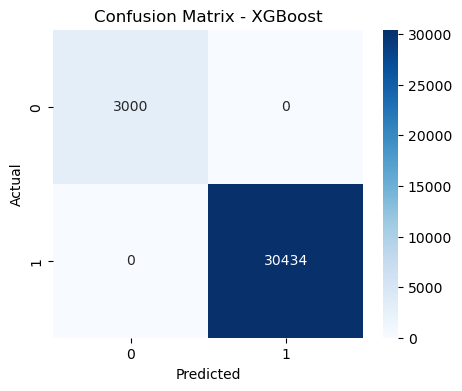

In [17]:
import seaborn as sns

for name, model in models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


NameError: name 'xgb' is not defined